# Лабораторная работа 1. Текстовые эмбеддинги BERT

Цель работы: сравнить mean pooling и CLS pooling для классификации текстов. BERT не обучается, а используется как готовый генератор признаков.

Схема эксперимента: текст -> BERT -> эмбеддинг размером 768 -> Logistic Regression -> метрики.

## 1. Установка и импорт библиотек

Перед первым запуском нужно перейти в корень репозитория и установить общие зависимости через `uv`:

```bash
uv sync
uv run jupyter lab lab1_text_embeddings/lab1.ipynb
```

Для воспроизводимости фиксируем случайное зерно. На macOS будет использован MPS, если он доступен. На Linux может использоваться CUDA. Во всех остальных случаях вычисления идут на CPU.

In [1]:
from pathlib import Path
import warnings

warnings.filterwarnings("ignore", message="IProgress not found.*")

import numpy as np
import pandas as pd
import torch
from IPython import get_ipython

get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from transformers import AutoModel, AutoTokenizer

SEED = 42
warnings.filterwarnings(
    "ignore",
    message="`resume_download` is deprecated.*",
    category=FutureWarning,
)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Устройство: {device}")

Устройство: mps


## 2. Параметры эксперимента

Берём по 500 обучающих и 200 тестовых текстов каждого класса. Полный `ag_news` заметно больше, но для лабораторной такой выборки достаточно, а расчёт на CPU не занимает слишком много времени.

Если компьютер слабый, можно уменьшить `TRAIN_PER_CLASS`, `TEST_PER_CLASS` или `BATCH_SIZE`. Если памяти достаточно, `BATCH_SIZE` можно увеличить.

In [2]:
MODEL_NAME = "bert-base-multilingual-cased"
TRAIN_PER_CLASS = 500
TEST_PER_CLASS = 200
BATCH_SIZE = 16
MAX_LENGTH = 128

## 3. Загрузка и подготовка данных

`ag_news` содержит четыре класса новостей: World, Sports, Business и Sci/Tech. Выборку делаем сбалансированной, чтобы в каждом классе было одинаковое число примеров.

In [3]:
dataset = load_dataset("ag_news")
label_names = dataset["train"].features["label"].names

print(dataset)
print("Классы:", label_names)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
Классы: ['World', 'Sports', 'Business', 'Sci/Tech']


In [4]:
def balanced_sample(split, n_per_class, seed):
    labels = np.asarray(split["label"])
    random_generator = np.random.default_rng(seed)
    selected_indices = []

    for label in np.unique(labels):
        class_indices = np.flatnonzero(labels == label)
        chosen = random_generator.choice(
            class_indices, size=n_per_class, replace=False
        )
        selected_indices.extend(chosen.tolist())

    random_generator.shuffle(selected_indices)
    return split.select(selected_indices)


train_data = balanced_sample(dataset["train"], TRAIN_PER_CLASS, SEED)
test_data = balanced_sample(dataset["test"], TEST_PER_CLASS, SEED + 1)

print(f"Обучающих текстов: {len(train_data)}")
print(f"Тестовых текстов: {len(test_data)}")

Обучающих текстов: 2000
Тестовых текстов: 800


In [5]:
preview = pd.DataFrame(train_data[:5])
preview["class_name"] = preview["label"].map(dict(enumerate(label_names)))
preview[["text", "label", "class_name"]]

,text,label,class_name
0,IAEA concludes second investigation in S. Kore...,0,World
1,Cricket: Ponting gives thumbs up Australia cap...,1,Sports
2,Wireless data gamble Kent Thexton took a gam...,3,Sci/Tech
3,Former CA CEO Charged with Fraud Former Comput...,2,Business
4,"Even in win, nasty vibes ATHENS -- As you saw ...",1,Sports


In [6]:
train_distribution = (
    pd.Series(train_data["label"])
    .map(dict(enumerate(label_names)))
    .value_counts()
    .sort_index()
)
test_distribution = (
    pd.Series(test_data["label"])
    .map(dict(enumerate(label_names)))
    .value_counts()
    .sort_index()
)

pd.DataFrame({"train": train_distribution, "test": test_distribution})

,train,test
Business,500,200
Sci/Tech,500,200
Sports,500,200
World,500,200


## 4. Загрузка BERT

Модель переводится в режим `eval`. Градиенты не считаются, потому что BERT не обучается.

In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModel.from_pretrained(MODEL_NAME).to(device)
bert_model.eval()

print(f"Размер скрытого представления: {bert_model.config.hidden_size}")

Размер скрытого представления: 768


## 5. Получение эмбеддингов

BERT возвращает тензор размера `(batch, seq_len, 768)`. То есть для каждого токена есть свой вектор.

Mean pooling усредняет настоящие токены. Padding не учитывается с помощью `attention_mask`:

$$e_{mean} = \frac{\sum_i h_i m_i}{\sum_i m_i}$$

CLS pooling берёт первый вектор последовательности:

$$e_{CLS} = h_0$$

Оба варианта считаются за один проход BERT, чтобы не выполнять одну и ту же тяжёлую работу два раза.

In [8]:
def get_embeddings(texts, batch_size=BATCH_SIZE):
    mean_batches = []
    cls_batches = []

    batch_starts = range(0, len(texts), batch_size)
    total_batches = len(batch_starts)

    for batch_number, start in enumerate(batch_starts, start=1):
        batch_texts = texts[start:start + batch_size]
        tokens = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
        )
        tokens = {name: value.to(device) for name, value in tokens.items()}

        with torch.inference_mode():
            hidden_states = bert_model(**tokens).last_hidden_state

        attention_mask = tokens["attention_mask"].unsqueeze(-1)
        attention_mask = attention_mask.to(hidden_states.dtype)
        token_sum = (hidden_states * attention_mask).sum(dim=1)
        token_count = attention_mask.sum(dim=1).clamp(min=1)
        mean_embeddings = token_sum / token_count
        cls_embeddings = hidden_states[:, 0, :]

        mean_batches.append(mean_embeddings.cpu().numpy())
        cls_batches.append(cls_embeddings.cpu().numpy())

        if batch_number % 25 == 0 or batch_number == total_batches:
            processed = min(start + batch_size, len(texts))
            print(f"Обработано текстов: {processed}/{len(texts)}")

    return np.vstack(mean_batches), np.vstack(cls_batches)

In [9]:
X_train_mean, X_train_cls = get_embeddings(train_data["text"])
X_test_mean, X_test_cls = get_embeddings(test_data["text"])

y_train = np.asarray(train_data["label"])
y_test = np.asarray(test_data["label"])

print("Mean train:", X_train_mean.shape)
print("CLS train:", X_train_cls.shape)
print("Mean test:", X_test_mean.shape)
print("CLS test:", X_test_cls.shape)

Обработано текстов: 400/2000


Обработано текстов: 800/2000


Обработано текстов: 1200/2000


Обработано текстов: 1600/2000


Обработано текстов: 2000/2000


Обработано текстов: 400/800


Обработано текстов: 800/800
Mean train: (2000, 768)
CLS train: (2000, 768)
Mean test: (800, 768)
CLS test: (800, 768)


## 6. Обучение классификаторов

Для каждого вида эмбеддингов обучается отдельная Logistic Regression. Настройки одинаковые, поэтому сравнение получается честным.

In [10]:
classifier_mean = LogisticRegression(max_iter=1000, random_state=SEED)
classifier_cls = LogisticRegression(max_iter=1000, random_state=SEED)

classifier_mean.fit(X_train_mean, y_train)
classifier_cls.fit(X_train_cls, y_train)

predictions_mean = classifier_mean.predict(X_test_mean)
predictions_cls = classifier_cls.predict(X_test_cls)

## 7. Метрики и сохранение результата

Используем accuracy и macro F1. Macro F1 полезен тем, что каждый класс одинаково влияет на итоговое значение.

In [11]:
metrics = pd.DataFrame([
    {
        "method": "mean",
        "accuracy": accuracy_score(y_test, predictions_mean),
        "f1_macro": f1_score(y_test, predictions_mean, average="macro"),
    },
    {
        "method": "CLS",
        "accuracy": accuracy_score(y_test, predictions_cls),
        "f1_macro": f1_score(y_test, predictions_cls, average="macro"),
    },
])

results_directory = Path("results")
results_directory.mkdir(exist_ok=True)
metrics.round(4).to_csv(results_directory / "metrics.csv", index=False)

metrics.round(4)

,method,accuracy,f1_macro
0,mean,0.8425,0.8429
1,CLS,0.8175,0.8182


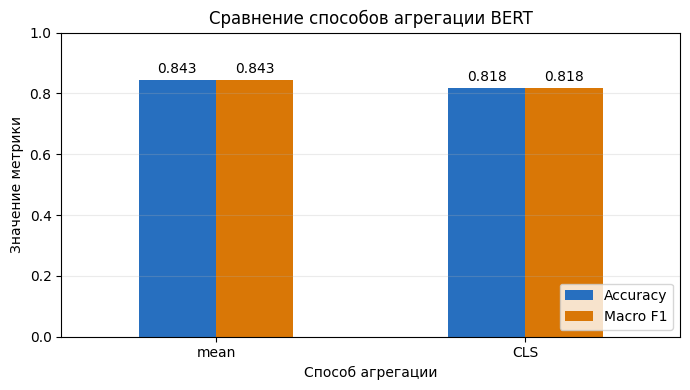

In [12]:
plot_data = metrics.set_index("method")[["accuracy", "f1_macro"]]
axis = plot_data.plot(
    kind="bar",
    figsize=(7, 4),
    color=["#276FBF", "#D97706"],
    ylim=(0, 1),
    rot=0,
)
axis.set_title("Сравнение способов агрегации BERT")
axis.set_xlabel("Способ агрегации")
axis.set_ylabel("Значение метрики")
axis.grid(axis="y", alpha=0.25)
axis.legend(["Accuracy", "Macro F1"], loc="lower right")

for container in axis.containers:
    axis.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()

## 8. Проверка и вывод

Следующая ячейка проверяет основные условия эксперимента и печатает простой вывод на основе полученных значений.

In [13]:
assert X_train_mean.shape == X_train_cls.shape
assert X_test_mean.shape == X_test_cls.shape
assert X_train_mean.shape[1] == bert_model.config.hidden_size == 768
assert metrics[["accuracy", "f1_macro"]].to_numpy().min() >= 0
assert metrics[["accuracy", "f1_macro"]].to_numpy().max() <= 1

best_row = metrics.loc[metrics["f1_macro"].idxmax()]
other_row = metrics.loc[metrics["f1_macro"].idxmin()]
difference = best_row["f1_macro"] - other_row["f1_macro"]

print("Все проверки пройдены.")
print(
    f"Лучший результат по macro F1 показал метод {best_row['method']}: "
    f"{best_row['f1_macro']:.4f}. Разница между методами: {difference:.4f}."
)

Все проверки пройдены.
Лучший результат по macro F1 показал метод mean: 0.8429. Разница между методами: 0.0247.


### Итог

В работе модель BERT использовалась без дообучения. Из одного набора токенных представлений были получены эмбеддинги mean и CLS. Затем на каждом варианте была обучена Logistic Regression.

Mean pooling показал accuracy 0.8425 и macro F1 0.8429. Для CLS pooling получены accuracy 0.8175 и macro F1 0.8182. На выбранной тестовой выборке mean pooling оказался лучше по macro F1 на 0.0247. Результат относится к выбранной модели, датасету и размеру выборки.

## 9. Вопросы для защиты

**Почему BERT выдаёт не один вектор?**  
BERT работает с токенами и возвращает отдельный вектор каждого токена. Чтобы получить один вектор текста, нужна агрегация.

**Чем отличаются mean и CLS?**  
Mean pooling использует представления всех настоящих токенов. CLS pooling берёт только представление специального токена `[CLS]`.

**Почему padding нельзя включать в среднее?**  
Padding добавляется только для выравнивания длины текстов в батче и не несёт смысла. Если его усреднять вместе с текстом, результат будет зависеть от числа добавленных токенов.

**Почему BERT не обучается?**  
Задача лабораторной состоит в сравнении способов агрегации. Дообучение BERT изменило бы сами представления и усложнило сравнение.

**Почему CLS не обязательно окажется лучше?**  
Обычный предобученный BERT не оптимизировался специально для получения эмбеддинга предложения через CLS. Поэтому качество проверяется на задаче классификации.

**Почему выбрана Logistic Regression?**  
Это простой линейный классификатор. Он позволяет сравнить качество эмбеддингов без сложной модели поверх них.